In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))
import torch
import sys
import geopandas as gpd
import pandas as pd
from matplotlib.patches import Patch


sys.path.append('./satclip/satclip')

from matplotlib import pyplot as plt
from dotenv import load_dotenv
import os

load_dotenv()
import random
import numpy as np

from notebooks.construct_dataset.shared_utils import plot_aez_counts, sample_gdf, get_new_random_seed, assert_geodataframes_equal


try:
    RANDOM_SEED = int(os.environ["RANDOM_SEED"])
except:
    RANDOM_SEED = 15


random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

TRAIN_FOLDS = os.environ.get("TRAIN_FOLDS", [0,1,2])
VALID_FOLDS = os.environ.get("VALID_FOLDS", [3])
TEST_FOLDS = os.environ.get("TEST_FOLDS", [4])

AEZ_ROOT = os.getenv("AEZ_ROOT", "data/aez")
GPKGS_ROOT = os.getenv("GPKGS_ROOT", "data/gpkgs")


BASE_ASSET_PATH = os.environ.get("BASE_ASSET_PATH")

if BASE_ASSET_PATH.endswith(".parquet"):
    gdf = gpd.read_parquet(BASE_ASSET_PATH)
else:
    gdf = gpd.read_file(BASE_ASSET_PATH)

aez_number_to_class_label = {}
with open(f"../../{AEZ_ROOT}/AEZ_57classes.clr", "r") as infile:
    for line in infile:
        parts = line.strip().split()
        aez_number_to_class_label[int(parts[0])] = " ".join(parts[5:])

aez_number_to_class_label[0] = "Unclassified"


/home/nathan/Desktop/BDA_integration/.venv/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(


In [2]:
gdf = gdf[gdf["tile"] != -1]
len(pd.unique(gdf["tile"]))

30

In [4]:
print(len(gdf))
value_counts = gdf["tile"].value_counts()
if -1 in value_counts.index:
        value_counts = value_counts.drop(index=[-1])
mean_count = value_counts.mean()
threshold = 0#0.05 * mean_count
keep_tiles = list(value_counts[value_counts > threshold].index.values)
gdf = gdf[gdf["tile"].isin(keep_tiles)]
print(len(gdf))

495307
495307


In [5]:
value_pcts = gdf["tile"].value_counts().apply(lambda x: x / len(gdf))

In [6]:
child_rng = np.random.default_rng(get_new_random_seed())
child_rng.shuffle(keep_tiles)

tile_groups = {}
N_GROUPS = 5

def build_evenly_sized_groups():
    groups = {i:[] for i in range(N_GROUPS)}
    group_weights = [0] * N_GROUPS

    for t in keep_tiles:
        inds = sorted([i for i in range(N_GROUPS)], key=(lambda x: group_weights[x]))
        min_ind = inds.pop(0)
        while len(groups[min_ind]) >= (len(keep_tiles) / N_GROUPS):
            min_ind = inds.pop(0)
        groups[min_ind].append(t)
        group_weights[min_ind] += value_pcts[t]


    return groups

groups = np.split(np.array(keep_tiles), indices_or_sections=N_GROUPS)

groups

[array([28, 31, 12, 11,  4,  7]),
 array([ 0, 19, 34, 20, 17,  8]),
 array([15,  5, 16, 22,  9, 27]),
 array([29, 25,  1, 33, 21, 10]),
 array([35, 14, 26, 13,  6, 32])]

<Axes: >

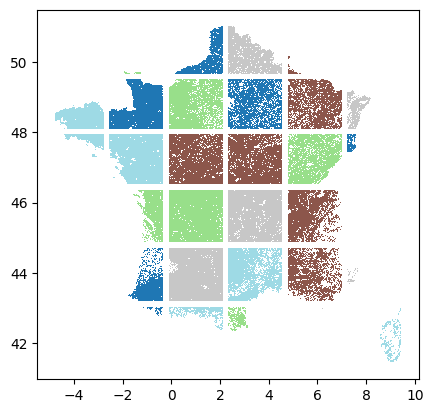

In [7]:
tile_groups = {
    i:groups[i] for i in range(len(groups))
}

reverse_tile_groups = {}

for g in tile_groups:
    vals = tile_groups[g]
    for v in vals:
        reverse_tile_groups[v] = g

cmap = plt.cm.tab20(np.linspace(0, 1, len(groups)))
group_assignments = [reverse_tile_groups[i] for i in gdf["tile"]]
gdf["tile_group"] = group_assignments

colors = [cmap[i] for i in gdf["tile_group"]]

gdf.plot(color=colors)

In [8]:
vcs = pd.Series(gdf["tile_group"]).value_counts().sort_index()
vcs

tile_group
0     75861
1    106159
2    136767
3     94553
4     81967
Name: count, dtype: int64

<BarContainer object of 5 artists>

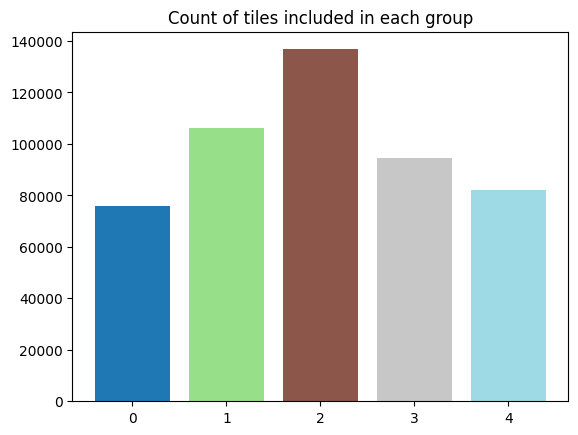

In [9]:
inds = list(vcs.index)
vals = list(vcs.values)
plt.title("Count of tiles included in each group")
plt.bar(x=inds, height=vals, color=[cmap[i] for i in inds])

In [10]:
gdf.columns

Index(['hedgerows', 'aez_class', 'thz_class', 'mst_class', 'fold',
       'plot_color', 'quadrant', 'sixteenth', 'tile', 'geometry',
       'tile_group'],
      dtype='object')

In [11]:
gdf["fold"]

3         2
4         2
5         2
6        -1
7         3
         ..
603080    0
603081    0
603082    0
603083    0
603084    0
Name: fold, Length: 495307, dtype: int64

In [12]:
# def sample_gdf(gdf, folds, split, n_per_fold=600):
#     dfs = []

#     value_pcts = gdf["tile"].value_counts().apply(lambda x: x / len(gdf))
#     for f in folds:
#         inner_gdfs = []
#         for t in pd.unique(gdf["tile"]):
#             sub_gdf = gdf[(gdf["tile"] == t) & (gdf["fold"] == f)]
#             if len(sub_gdf) == 0:
#                 continue
#             pct = float(value_pcts.loc[t]) 
#             child_rng = np.random.default_rng(get_new_random_seed())
#             n_t = n_per_fold * pct

#             inds = child_rng.choice([i for i in range(len(sub_gdf))], int(round(n_t)))
#             sub_gdf_sampled = sub_gdf.iloc[inds]
#             inner_gdfs.append(sub_gdf_sampled)
        
#         full_inner_gdf = pd.concat(inner_gdfs, axis=0)
#         dfs.append(full_inner_gdf)
#     full_gdf = pd.concat(dfs, axis=0)
#     full_gdf["split"] = [split] * len(full_gdf)
#     return full_gdf
train_gdf = sample_gdf(gdf, TRAIN_FOLDS, "train")
valid_gdf = sample_gdf(gdf, VALID_FOLDS, "valid")
test_gdf = sample_gdf(gdf, TEST_FOLDS, "test")


In [13]:
len(train_gdf)


1797

In [14]:
train_gdf

,hedgerows,aez_class,thz_class,mst_class,fold,plot_color,quadrant,sixteenth,tile,geometry,tile_group,split
9597,"LINESTRING (-3.564846 48.731026, -3.564828 48....","Sub-tropics, cool; humid, with soil/terrain li...","TRC5: Subtropics, cool",270-365 days,0,[0.83921569 0.15294118 0.15686275 1. ],0,0,6,"POLYGON ((-3.57586 48.72921, -3.56436 48.72921...",4,train
3832,"MULTILINESTRING ((-4.149606 48.415644, -4.1496...","Temperate, cool; wet, with soil/terrain limita...","TRC7: Temperate, cool",270-365 days,0,[0.83921569 0.15294118 0.15686275 1. ],0,0,6,"POLYGON ((-4.15078 48.40965, -4.13928 48.40965...",4,train
3937,"MULTILINESTRING ((-4.137338 48.386744, -4.1372...","Temperate, cool; wet, with soil/terrain limita...","TRC7: Temperate, cool",270-365 days,0,[0.83921569 0.15294118 0.15686275 1. ],0,0,6,"POLYGON ((-4.13928 48.37911, -4.12778 48.37911...",4,train
13149,"MULTILINESTRING ((-3.286345 48.348549, -3.2862...","Sub-tropics, cool; humid, with soil/terrain li...","TRC5: Subtropics, cool",270-365 days,0,[0.83921569 0.15294118 0.15686275 1. ],0,0,6,"POLYGON ((-3.2884 48.34855, -3.2769 48.34855, ...",4,train
10680,"MULTILINESTRING ((-3.483869 48.465381, -3.4835...","Sub-tropics, cool; humid, no soil/terrain limi...","TRC5: Subtropics, cool",270-365 days,0,[0.83921569 0.15294118 0.15686275 1. ],0,0,6,"POLYGON ((-3.48387 48.46305, -3.47237 48.46305...",4,train
...,...,...,...,...,...,...,...,...,...,...,...,...
598180,"MULTILINESTRING ((7.69987 48.383676, 7.69991 4...","Temperate, cool; wet, no soil/terrain limitations","TRC7: Temperate, cool",270-365 days,2,[0.58039216 0.40392157 0.74117647 1. ],1,1,10,"POLYGON ((7.69261 48.37911, 7.70411 48.37911, ...",3,train
603048,"MULTILINESTRING ((9.447528 42.544506, 9.447518...",Ample irrigated soils,"TRC4: Subtropics, moderately cool",225-270 days,2,[0.58039216 0.40392157 0.74117647 1. ],3,3,35,"POLYGON ((9.44037 42.53962, 9.45187 42.53962, ...",4,train
602685,"MULTILINESTRING ((9.38288 42.005103, 9.382947 ...",Ample irrigated soils,"TRC4: Subtropics, moderately cool",225-270 days,2,[0.58039216 0.40392157 0.74117647 1. ],3,3,35,"POLYGON ((9.38288 42.0036, 9.39438 42.0036, 9....",4,train
603042,"LINESTRING (9.44647 42.495318, 9.446616 42.495...","Sub-tropics, mod. cool; sub-humid, with soil/t...","TRC4: Subtropics, moderately cool",225-270 days,2,[0.58039216 0.40392157 0.74117647 1. ],3,3,35,"POLYGON ((9.44037 42.48877, 9.45187 42.48877, ...",4,train


In [15]:
aez_class_subgroups = {
    "Sub-tropics, cool": [
        "Sub-tropics, cool; humid, no soil/terrain limitations",
        "Sub-tropics, cool; sub-humid, with soil/terrain limitations",
        "Sub-tropics, cool; sub-humid, no soil/terrain limitations",
    ],
    "Sub-tropics, mod.cool": [
        "Sub-tropics, mod. cool; humid, no soil/terrain limitations",
        "Sub-tropics, mod. cool; sub-humid, no soil/terrain limitations",
        "Sub-tropics, mod. cool; humid, with soil/terrain limitations",
        "Sub-tropics, mod. cool; sub-humid, with soil/terrain limitations"
    ],

    "Temperate, cool, moist": [
        "Temperate, cool; moist, no soil/terrain limitations",
        "Temperate, cool; moist, with soil/terrain limitations",
    ],

    "Temperate, cool, wet": [
        "Temperate, cool; wet, with soil/terrain limitations",
        "Temperate, cool; wet, no soil/terrain limitations",
    ],

    
    "Temperate, moderate": [
        "Temperate, moderate; moist, with soil/terrain limitations",
        "Temperate, moderate; moist, no soil/terrain limitations"
    ],

    "Terrain-dominated": [
        "Dominantly hydromorphic soils",
        "Dominantly very steep terrain",
        "Dominantly built-up land",
    ],

    "Misc": [
        "Ample irrigated soils",
        "Land with severe soil/terrain limitations",
        "Unclassified"
    ],
    
}

In [16]:
for k in aez_class_subgroups:
    print(k)
    print(len(train_gdf[train_gdf["aez_class"].isin(aez_class_subgroups[k])]))

Sub-tropics, cool
140
Sub-tropics, mod.cool
89
Temperate, cool, moist
559
Temperate, cool, wet
710
Temperate, moderate
0
Terrain-dominated
62
Misc
171


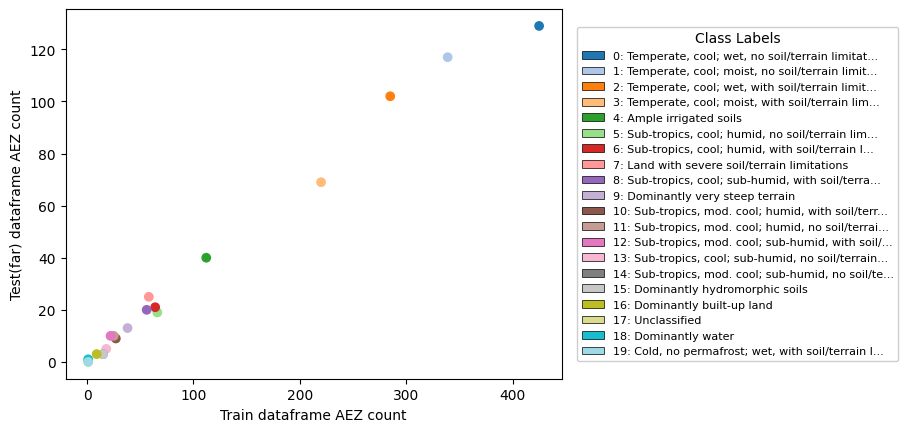

In [17]:
value_counts = train_gdf["aez_class"].value_counts().sort_values(ascending=False)
test_far_value_counts = test_gdf["aez_class"].value_counts().sort_index()
test_far_value_counts = test_far_value_counts.reindex(value_counts.index, fill_value=0)
colors = plt.cm.tab20(np.arange(len(value_counts)))
class_to_color = {class_name: colors[i] for i, class_name in enumerate(value_counts.index)}

plt.xlabel("Train dataframe AEZ count")
plt.ylabel("Test(far) dataframe AEZ count")
plt.scatter(x=value_counts, y=test_far_value_counts, c=colors)

legend_labels = [f"{i}: {str(label)[:45]}{'...' if len(str(label)) > 45 else ''}" 
                for i, label in enumerate(value_counts.index)]
legend_handles = [Patch(facecolor=colors[i], edgecolor='black', linewidth=0.5) 
                    for i in range(len(value_counts))]

plt.legend(legend_handles, legend_labels,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        framealpha=0.95,
        title='Class Labels',
        title_fontsize=10,
        ncol=1)
plt.show()


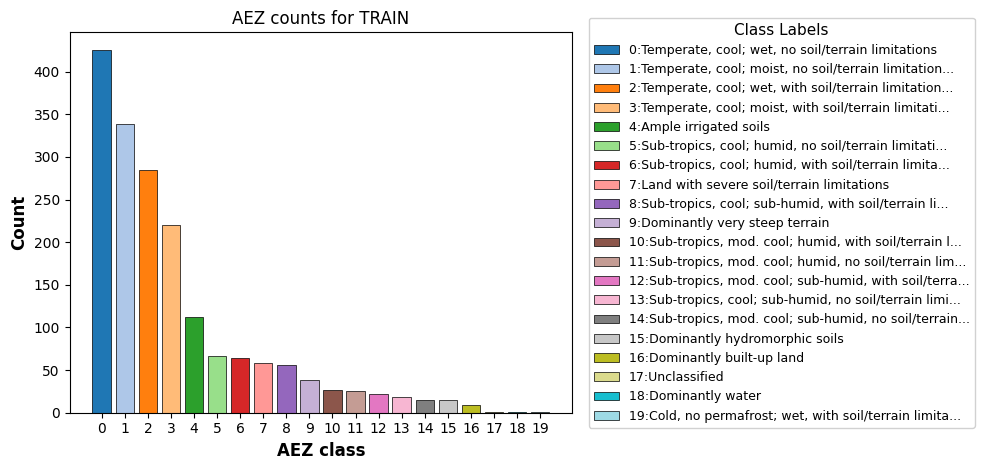

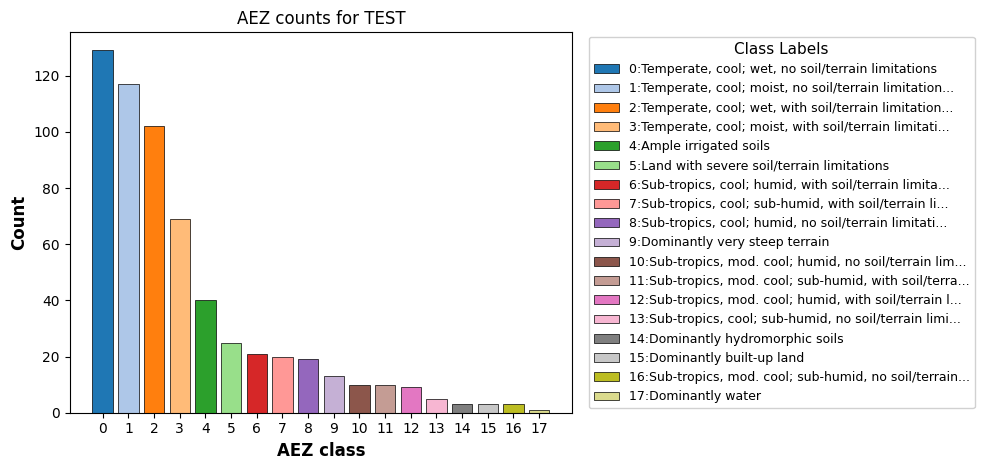

In [18]:



plot_aez_counts(train_gdf, colors=colors, title="AEZ counts for TRAIN")
plot_aez_counts(test_gdf, colors=colors, title="AEZ counts for TEST")


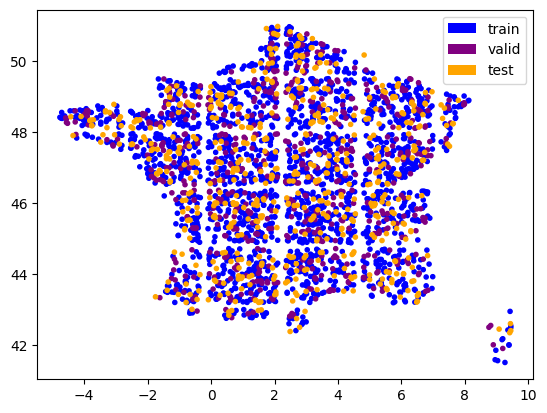

In [19]:
dataset = pd.concat([train_gdf, valid_gdf, test_gdf])


xs = []
ys = []
colors = []

split_to_col = {
    "train": "blue",
    "valid": "purple",
    "test": "orange",
}

for i in range(len(dataset)):
    row = dataset.iloc[i]
    x,y = row.geometry.centroid.xy
    color = split_to_col[row["split"]]
    xs.append(x)
    ys.append(y)
    colors.append(color)

plt.scatter(x=xs, y=ys, c=colors, marker=".")
legend_elements = [Patch(facecolor=color, label=label) 
                   for label, color in split_to_col.items()]
plt.legend(handles=legend_elements)
plt.show()

In [20]:
other_gdf = gpd.read_file(f"../../{GPKGS_ROOT}/hedgementation_dataset_1.2.gpkg")
metadata = gpd.read_file("/scratch/nathan/data/hedgementation_1.2/metadata.geojson")
dataset = dataset.set_index(pd.RangeIndex(0,len(dataset)))


In [21]:
metadata = gpd.read_file("/scratch/nathan/data/hedgementation_1.2/metadata.geojson")
pd.unique(metadata["tile_group"])

array([4, 0, 1, 3, 2], dtype=int32)

In [22]:
dataset.index

RangeIndex(start=0, stop=2995, step=1)

In [23]:
dataset["split"].equals(other_gdf["split"])

True

In [24]:
other_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [25]:
assert_geodataframes_equal(dataset, other_gdf, geom_only=True)

In [26]:
assert_geodataframes_equal(metadata, other_gdf, geom_only=True)

In [27]:
assert_geodataframes_equal(dataset, other_gdf)

In [28]:
for col in dataset.columns:
    print(col)
    print(dataset[col].equals(other_gdf[col]))

hedgerows
True
aez_class
True
thz_class
True
mst_class
True
fold
True
plot_color
True
quadrant
True
sixteenth
True
tile
True
geometry
True
tile_group
True
split
True


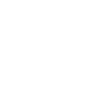

In [29]:
import shapely
shapely.wkt.loads(other_gdf["hedgerows"].iloc[0])

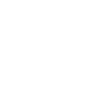

In [30]:
shapely.wkt.loads(dataset["hedgerows"].iloc[0])

In [31]:
pd.testing.assert_frame_equal(
    dataset.reindex(sorted(dataset.columns), axis=1),
    other_gdf.reindex(sorted(other_gdf.columns), axis=1),
    check_dtype=False
)

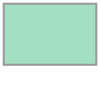

In [32]:
dataset["geometry"].iloc[0]

In [33]:
for col in other_gdf.columns:
    print(col)
    print(other_gdf[col].equals(dataset[col]))

hedgerows
True
aez_class
True
thz_class
True
mst_class
True
fold
True
plot_color
True
quadrant
True
sixteenth
True
tile
True
tile_group
True
split
True
geometry
True


In [ ]:
dataset.to_file(f"../../{GPKGS_ROOT}/hedgementation_dataset_1.2.gpkg")